In [1]:
import numpy as np
import ast
import pickle
import pandas as pd
from DQST_full_tomography import *
from helper import *
from GHZ_fidelity_estimation import *

# 1. DQST: Density matrix reconstruction

In [2]:
# 1) Load 4 qubit GHZ, 0, + state datas obtained from IBM aachen
df = pd.read_csv("DQST_full_reconstruction_data.csv")
df['GHZ'] = df['GHZ'].apply(ast.literal_eval)
df['0state'] = df['0state'].apply(ast.literal_eval)
df['+state'] = df['+state'].apply(ast.literal_eval)

# 2) load 4 qubit confusion matrix
confu_4q=pd.read_pickle("confusion_full_reconstruction.pkl")

# 3) obtain reconstructed density matrices ([0]: raw, [1]: physical density matrix)
rho_GHZ=DQST_full_tomography(df['GHZ'],10000)[1]
rho_0=DQST_full_tomography(df['0state'],10000)[1]
rho_p=DQST_full_tomography(df['+state'],10000)[1]

# 4) obtain QREM applied density matrix
rho_GHZ_mit=DQST_full_tomography(QREM_mitigated_counts(df['GHZ'],4,confu_4q),10000)[1]
rho_0_mit=DQST_full_tomography(QREM_mitigated_counts(df['0state'],4,confu_4q),10000)[1]
rho_p_mit=DQST_full_tomography(QREM_mitigated_counts(df['+state'],4,confu_4q),10000)[1]

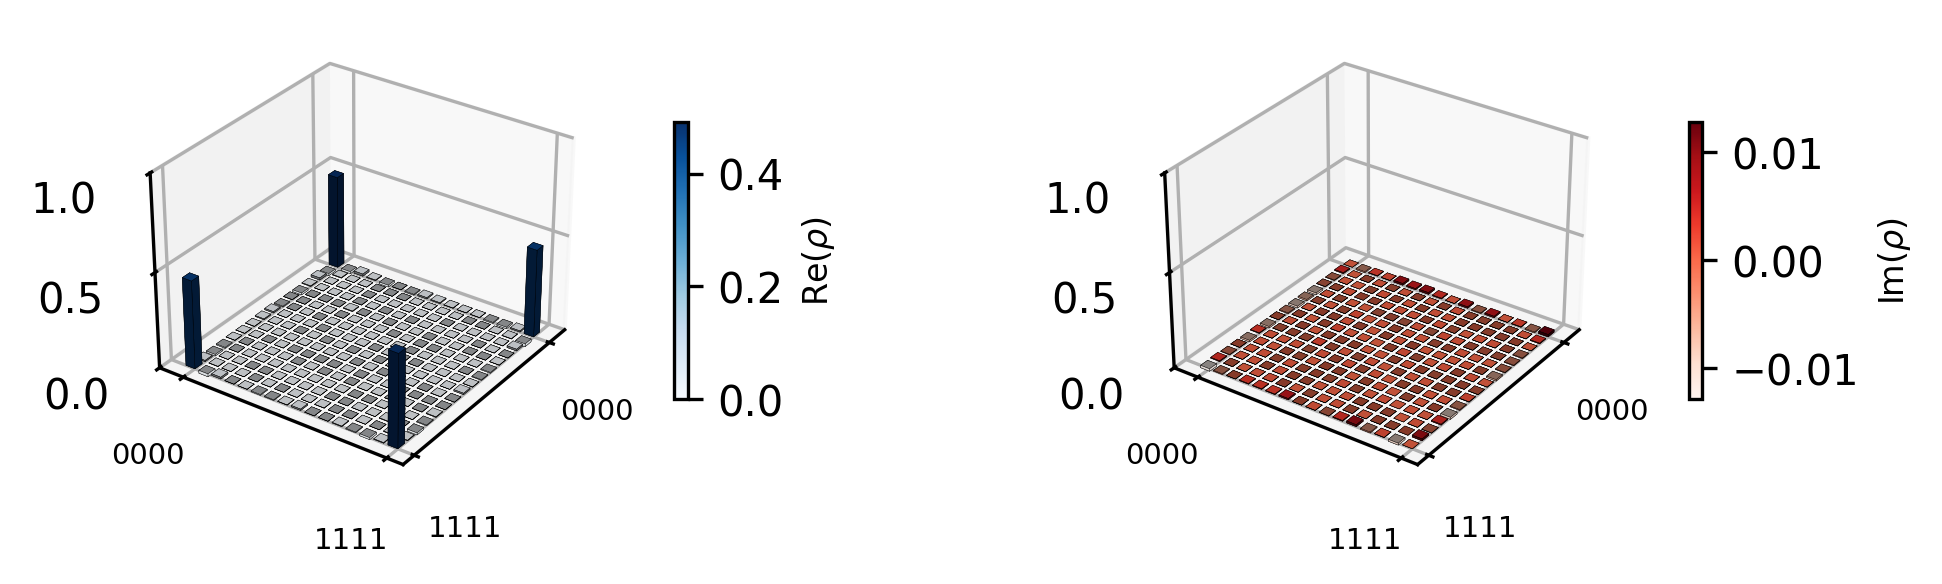

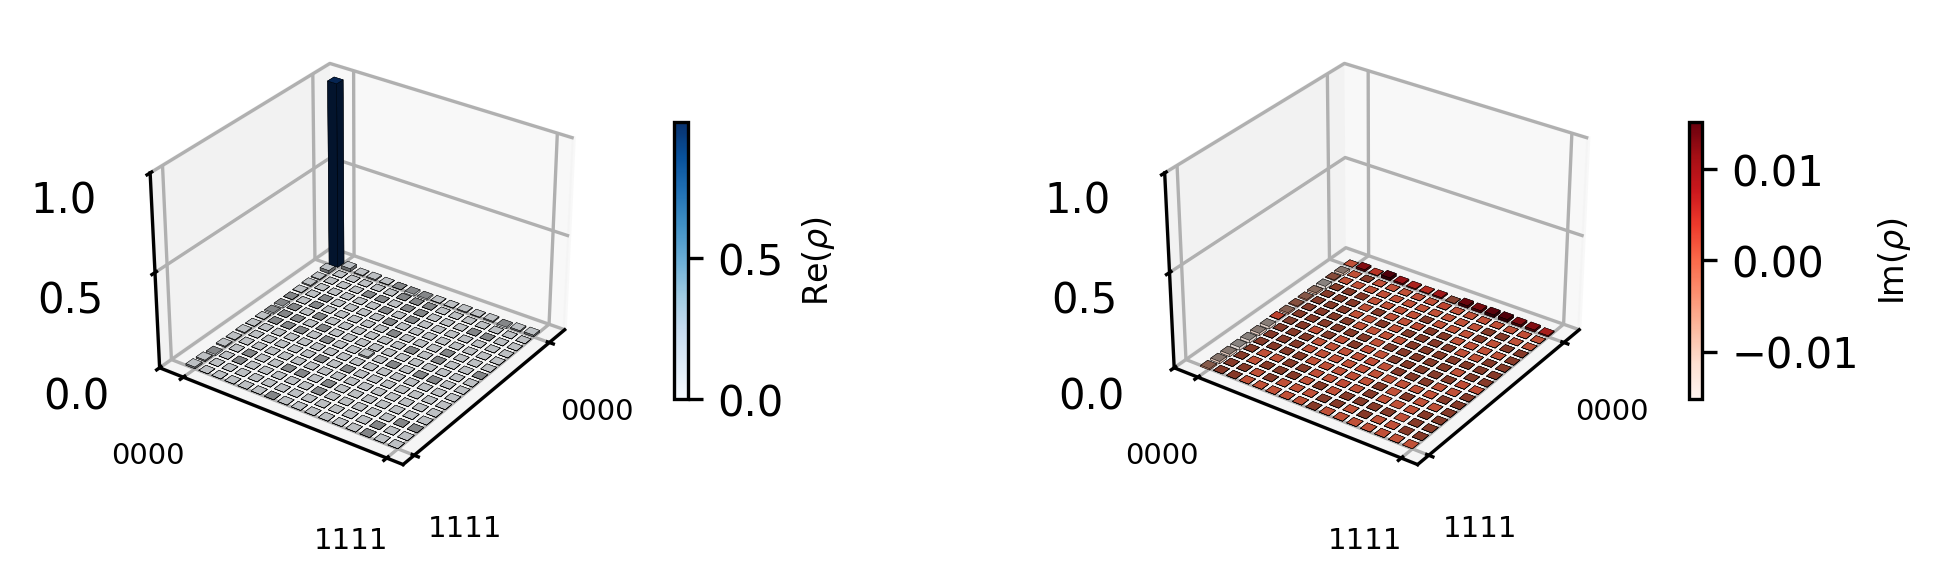

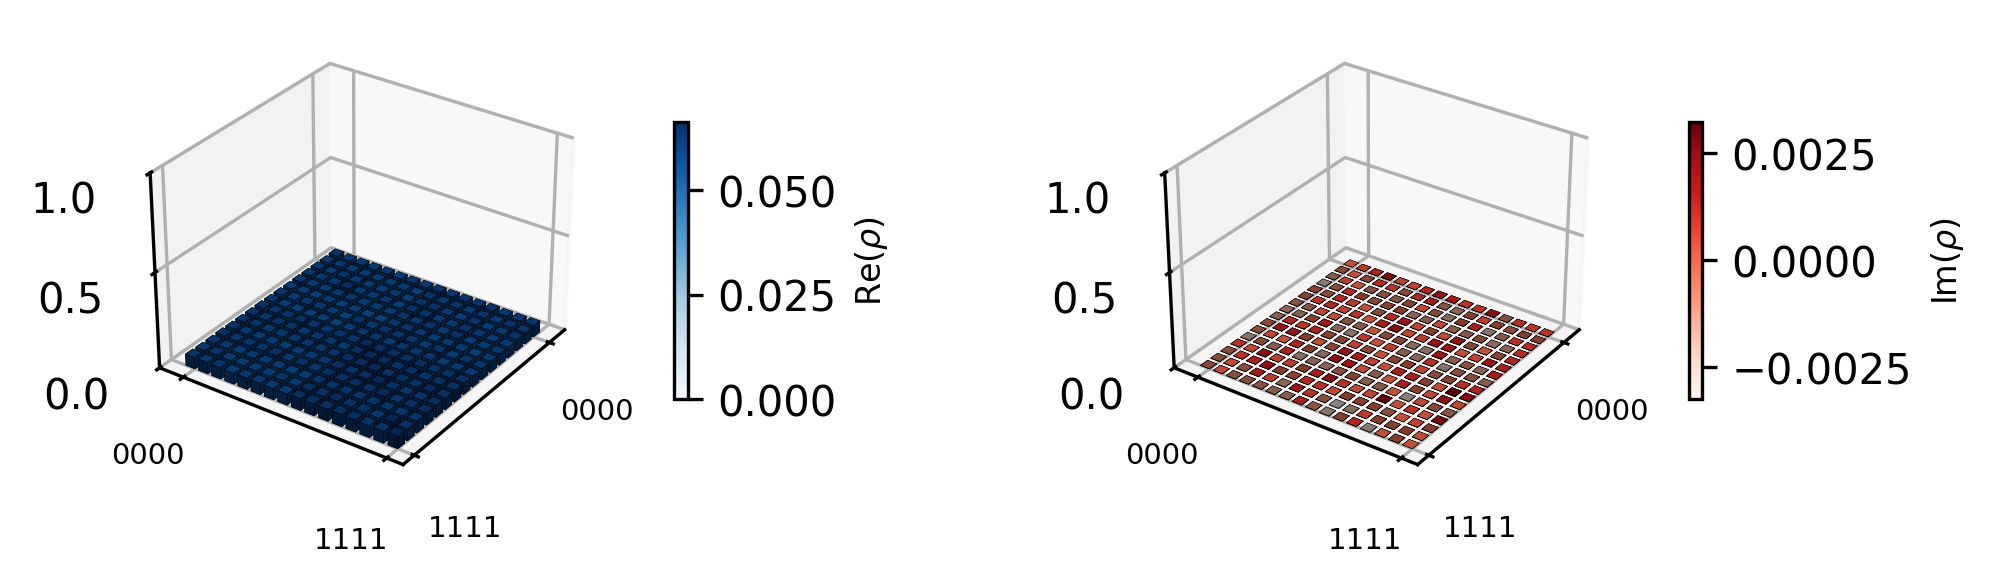

In [5]:
# 5) plot density matrix
visualize_DQST_results(rho_GHZ_mit,ideal_4q_GHZ())
visualize_DQST_results(rho_0_mit,ideal_4q_0())
visualize_DQST_results(rho_p_mit,ideal_4q_p())

In [4]:
# 6) uncertainties estimated over 500 resampling
print('----------- GHZ state ----------- ')
GHZ_result=statistical_analysis(df['GHZ'],confu_4q,ideal_4q_GHZ(),10000)
print('----------- |0000> state ----------- ')
zero_state_result=statistical_analysis(df['0state'],confu_4q,ideal_4q_0(),10000)
print('----------- |++++> state ----------- ')
plus_state_result=statistical_analysis(df['+state'],confu_4q,ideal_4q_p(),10000)

----------- GHZ state ----------- 
1) Without QREM:      96.34 ± 0.11 %
2) With QREM:         97.42 ± 0.11 %
----------- |0000> state ----------- 
1) Without QREM:      99.00 ± 0.06 %
2) With QREM:         99.30 ± 0.06 %
----------- |++++> state ----------- 
1) Without QREM:      97.57 ± 0.05 %
2) With QREM:         98.03 ± 0.05 %


# 2. DQST: GHZ fidelity estimation

/var/folders/xf/rm513wgn0tzf3rrlgmcrlwh40000gn/T/ipykernel_25382/3032243767.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_GHZ_fidest = df_GHZ_fidest.applymap(ast.literal_eval)


---------------- Results for GHZ fidelity estimation for n=4 ---------------- 
1) no ZNE, no QREM:      92.5 ± 0.1 %
2) no ZNE, with QREM:    94.4 ± 0.1 %
3) with ZNE, no QREM:    94.0 ± 0.2 %
4) with ZNE, with QREM:  95.9 ± 0.2 %
---------------- Results for GHZ fidelity estimation for n=5 ---------------- 
1) no ZNE, no QREM:      89.7 ± 0.1 %
2) no ZNE, with QREM:    92.0 ± 0.1 %
3) with ZNE, no QREM:    92.0 ± 0.1 %
4) with ZNE, with QREM:  94.3 ± 0.1 %
---------------- Results for GHZ fidelity estimation for n=6 ---------------- 
1) no ZNE, no QREM:      83.1 ± 0.2 %
2) no ZNE, with QREM:    86.9 ± 0.2 %
3) with ZNE, no QREM:    86.6 ± 0.3 %
4) with ZNE, with QREM:  90.5 ± 0.3 %
---------------- Results for GHZ fidelity estimation for n=7 ---------------- 
1) no ZNE, no QREM:      80.1 ± 0.1 %
2) no ZNE, with QREM:    84.0 ± 0.2 %
3) with ZNE, no QREM:    84.3 ± 0.2 %
4) with ZNE, with QREM:  88.5 ± 0.2 %
---------------- Results for GHZ fidelity estimation for n=8 ---------------

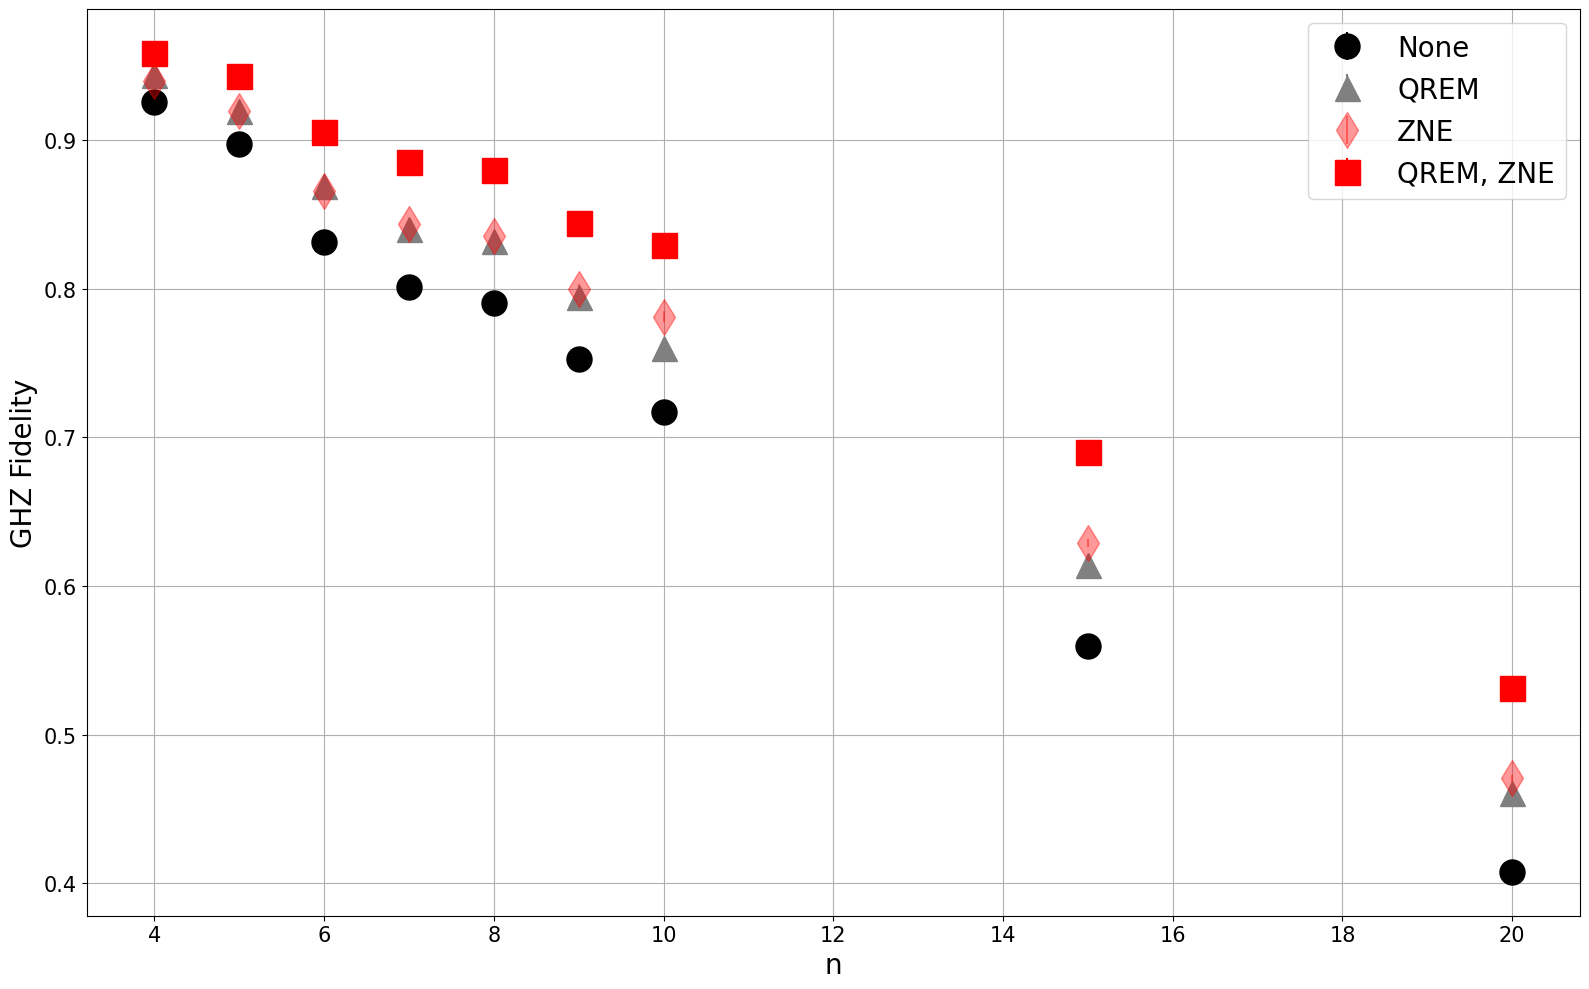

In [2]:
# 1)load IBM datas for n=4,5...20
df_GHZ_fidest = pd.read_csv("GHZ_fidelity_estimation_data.csv", header=[0,1],index_col=0)
df_GHZ_fidest = df_GHZ_fidest.applymap(ast.literal_eval)

# 2) create boot strap datas (50) using IBM data
ns = list(range(4, 11)) + [15, 20]
boot_data = {f'n={n}': Bootstrapped_data(df_GHZ_fidest[f'n={n}'], 50) for n in ns}

# 3) load 4,5,6,7,8,9,10,15,20 confusion matrices
df_confu = pd.read_pickle("confusion_GHZ_fidest.pkl")

# 4) result of GHZ fidelity estimation
visualize_GHZ_fidest_result(boot_data,df_confu,ns)